# 금융 거래 고객 신용 위험 예측
- 금융 거래 데이터 분석으로 고객 신용 위험 예측하는 분류 모델 설계

- 데이터 출처  
(원본) https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data  
(정제) https://www.kaggle.com/datasets/adityapotdar23/german-credit-data?resource=download

- 목차
1. 데이터 읽기
2. EDA 및 데이터 정제
3. 데이터 시각화
4. ML 모델에 학습위한 전처리
5. 모델 학습 및 평가
6. 예측 수행
7. 불균형 클래스 데이터 처리

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report

SEED = 42

sns.set_theme(style='whitegrid')

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
df_origin = pd.read_csv('data/german_credit_data.csv', index_col=0)
df_origin.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [3]:
df_origin.shape

(1000, 10)

- `Age`: 나이
- `Sex`: 성별
- `Job`: 직업 (직업 숙련도 정도로 볼 수 있습니다.)
    - 0: 비숙련직 및 비거주자 (unskilled and non-residnet)
    - 1: 비숙련직 및 거주자 (unskilled and resident)
    - 2: 숙련직 (skilled)
    - 3: 전문직 (highly skilled)
- `Housing`: 주거 형태
    - own: 자가
    - rent: 임대
    - free: (정확하지 않음) 정부나 기타 기관에서 지원해주는 주거 형태
- `Saving accounts:` 저축 예금의 잔고 정도
- `Checking account`: 당좌 예금의 잔고 정도
- `Credit amount`: 예금 보유량 (독일 마르크 기준)
- `Duration`: (정확하지 않음) 은행에 예금을 보유한 기간 (월단위)
- `Purpose`: 예금 보유 목적 (특정 물품 구매, 교육용, 휴가용 등등)

In [4]:
df_origin.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [5]:
df_origin.isna().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [6]:
df_origin['Saving accounts'].unique()

<StringArray>
[nan, 'little', 'quite rich', 'rich', 'moderate']
Length: 5, dtype: str

In [7]:
df_origin['Checking account'].unique()

<StringArray>
['little', 'moderate', nan, 'rich']
Length: 4, dtype: str

In [8]:
df_clean = df_origin.copy()
df_clean

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [9]:
df_clean['Checking account'] = df_clean['Checking account'].fillna('Others')
df_clean['Saving accounts'] = df_clean['Saving accounts'].fillna('Others')

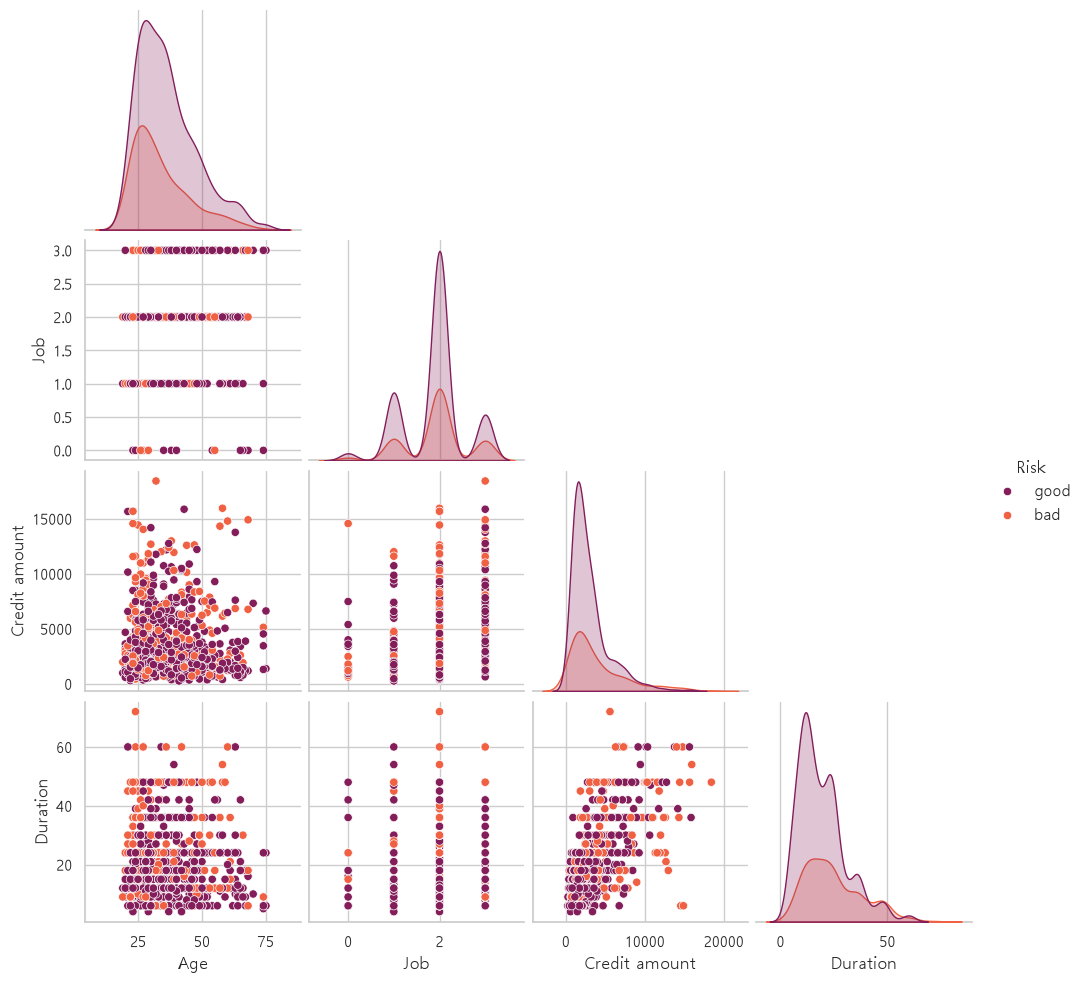

In [10]:
sns.pairplot(
    df_clean,
    vars=['Age', 'Job', 'Credit amount', 'Duration'],
    hue='Risk',
    palette='rocket',
    corner=True
)
plt.show()

Credit amount와 Duration은 약한 양의 상관관계  
Job과 Credit amount도 약한 양의 상관관계

<Axes: xlabel='Age', ylabel='Percent'>

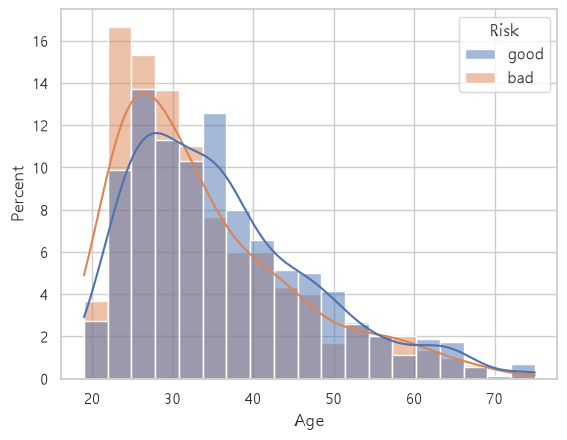

In [11]:
sns.histplot(df_clean, x='Age', hue='Risk', kde=True, stat='percent', common_norm=False)

저연령대에서 저신용자 많고, 30대에서 저신용자 많음

<Axes: xlabel='Sex', ylabel='Percent'>

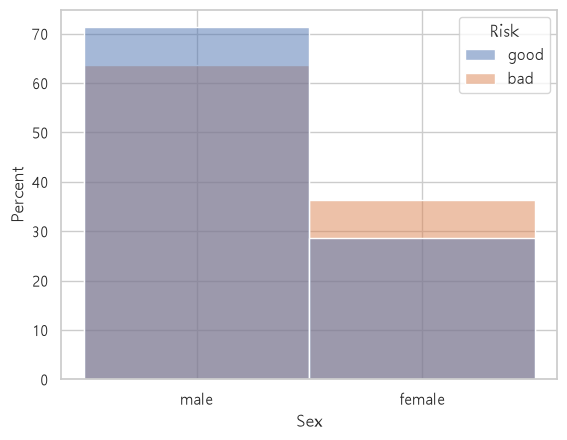

In [12]:
sns.histplot(df_clean, x='Sex', hue='Risk', stat='percent', common_norm=False)

남성이 여성보다 신용도 높음

<Axes: xlabel='Job', ylabel='Percent'>

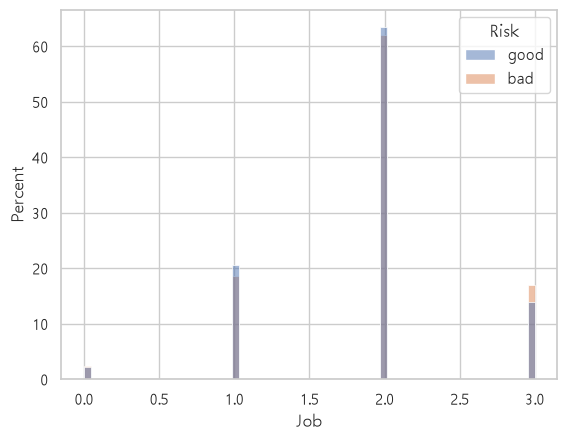

In [13]:
sns.histplot(df_clean, x='Job', hue='Risk', stat='percent', common_norm=False)

숙련직 신용도 좋고, 전문직은 다소 떨어지는 경향

<Axes: xlabel='Housing', ylabel='Percent'>

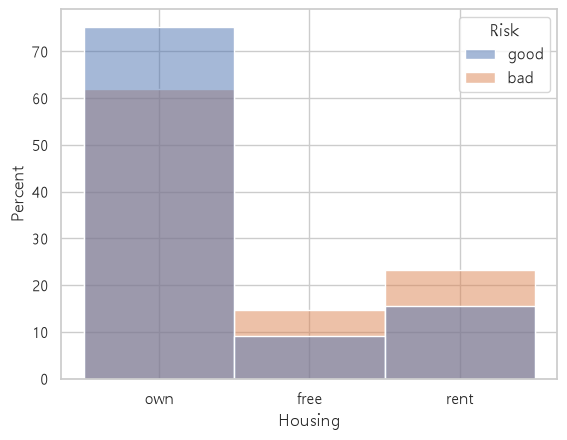

In [14]:
sns.histplot(df_clean, x='Housing', hue='Risk', stat='percent', common_norm=False)

자가가 신용도 높음

<Axes: xlabel='Checking account', ylabel='Percent'>

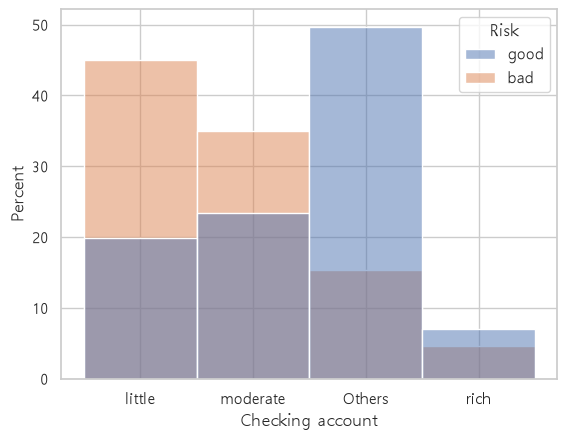

In [15]:
sns.histplot(df_clean, x='Checking account', hue='Risk', stat='percent', common_norm=False)

<Axes: xlabel='Saving accounts', ylabel='Percent'>

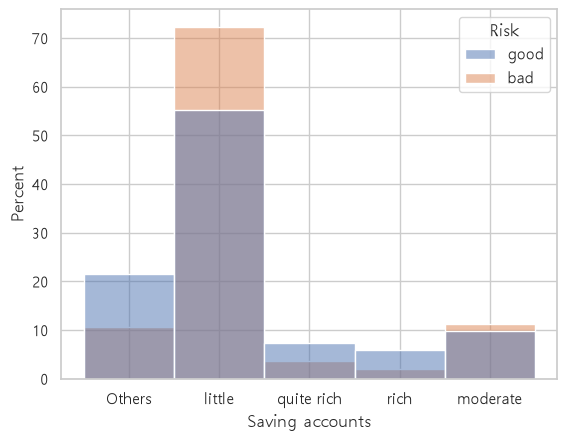

In [16]:
sns.histplot(df_clean, x='Saving accounts', hue='Risk', stat='percent', common_norm=False)

잔고 많으면 신용도 좋음

<Axes: xlabel='Credit amount', ylabel='Percent'>

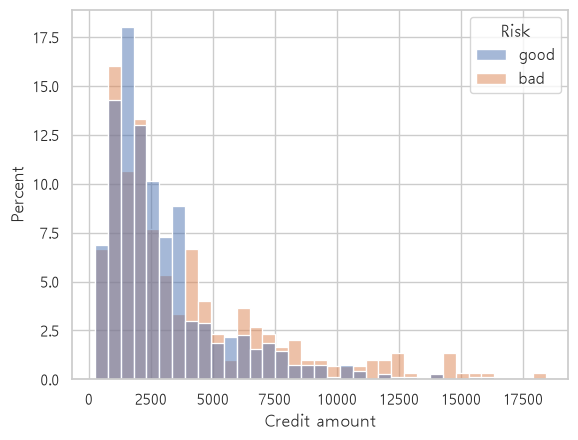

In [17]:
sns.histplot(df_clean, x='Credit amount', hue='Risk', stat='percent', common_norm=False)

현금보유량 많을수록 위험도 높은 사람 비율 높다

<Axes: xlabel='Duration', ylabel='Percent'>

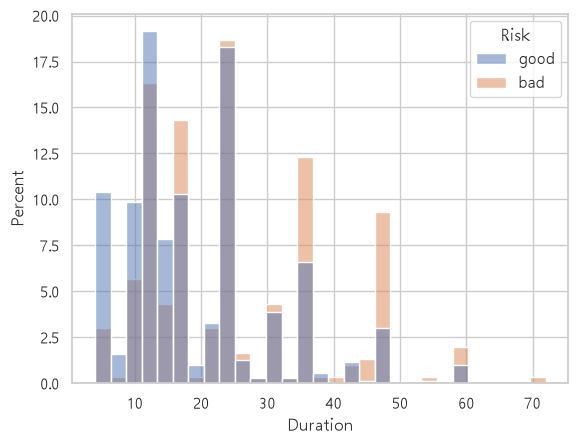

In [18]:
sns.histplot(df_clean, x='Duration', hue='Risk', stat='percent', common_norm=False)

예치 기간 길수록 신용도 낮은 사람 비율 높음

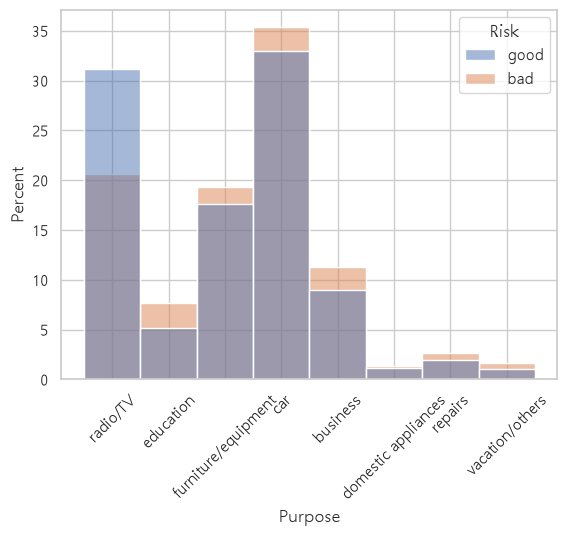

In [19]:
sns.histplot(df_clean, x='Purpose', hue='Risk', stat='percent', common_norm=False)
plt.xticks(rotation=45)
plt.show()

신용 위험도 낮은 사람은 생활용품 위해 예금하는 경향

4. 데이터 전처리
- 카테고리형 변수를 수치형으로 변환
- 학습 데이터와 테스트 데이터 나누기
- 정규화: 입력 변수들 값 크기 범위 조정

In [20]:
ord_encoder = OrdinalEncoder(dtype=np.int32)

non_numeric_features = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

df_clean[non_numeric_features] = ord_encoder.fit_transform(df_clean[non_numeric_features])
df_clean

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,0,1,1169,6,5,good
1,22,0,2,1,1,2,5951,48,5,bad
2,49,1,1,1,1,0,2096,12,3,good
3,45,1,2,0,1,1,7882,42,4,good
4,53,1,2,0,1,1,4870,24,1,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,0,1,1,1,0,1736,12,4,good
996,40,1,3,1,1,1,3857,30,1,good
997,38,1,2,1,1,0,804,12,5,good
998,23,1,2,0,1,1,1845,45,5,bad


In [21]:
ord_encoder.categories_

[array(['female', 'male'], dtype=object),
 array(['free', 'own', 'rent'], dtype=object),
 array(['Others', 'little', 'moderate', 'quite rich', 'rich'], dtype=object),
 array(['Others', 'little', 'moderate', 'rich'], dtype=object),
 array(['business', 'car', 'domestic appliances', 'education',
        'furniture/equipment', 'radio/TV', 'repairs', 'vacation/others'],
       dtype=object)]

In [22]:
df_clean['Risk'] = df_clean['Risk'].map({'good': 0, 'bad': 1})
df_clean

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,0,1,1169,6,5,0
1,22,0,2,1,1,2,5951,48,5,1
2,49,1,1,1,1,0,2096,12,3,0
3,45,1,2,0,1,1,7882,42,4,0
4,53,1,2,0,1,1,4870,24,1,1
...,...,...,...,...,...,...,...,...,...,...
995,31,0,1,1,1,0,1736,12,4,0
996,40,1,3,1,1,1,3857,30,1,0
997,38,1,2,1,1,0,804,12,5,0
998,23,1,2,0,1,1,1845,45,5,1


In [23]:
X = df_clean.drop('Risk', axis=1)
y = df_clean['Risk']
print(X.shape, y.shape)

(1000, 9) (1000,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(800, 9) (200, 9) (800,) (200,)


In [25]:
df_clean['Risk'].value_counts()

Risk
0    700
1    300
Name: count, dtype: int64

In [26]:
y_train.value_counts()

Risk
0    560
1    240
Name: count, dtype: int64

In [27]:
df_clean

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,0,1,1169,6,5,0
1,22,0,2,1,1,2,5951,48,5,1
2,49,1,1,1,1,0,2096,12,3,0
3,45,1,2,0,1,1,7882,42,4,0
4,53,1,2,0,1,1,4870,24,1,1
...,...,...,...,...,...,...,...,...,...,...
995,31,0,1,1,1,0,1736,12,4,0
996,40,1,3,1,1,1,3857,30,1,0
997,38,1,2,1,1,0,804,12,5,0
998,23,1,2,0,1,1,1845,45,5,1


In [28]:
scaler = MinMaxScaler()

feature_names = X.columns.tolist()

numeric_featues = ['Age', 'Credit amount', 'Duration']

X_train[numeric_featues] = scaler.fit_transform(X_train[numeric_featues])
X_test[numeric_featues] = scaler.transform(X_test[numeric_featues])

5. 모델 학습 및 평가
- LogisticRegression
- Naive Bayes
- Support Vector Machine
- DecisionTree / RandomForest
- XGBoost
- SoftVoting ensenble

In [29]:
lr_model = LogisticRegression(random_state=SEED)

lr_model.fit(X_train, y_train)
print('Done')

Done


In [30]:
def check_metrics(model, model_name, X_train, X_test, y_train, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    precision_train = precision_score(y_train, y_pred_train, zero_division=0)
    recall_train = recall_score(y_train, y_pred_train, zero_division=0)
    f1_train = f1_score(y_train, y_pred_train, zero_division=0, pos_label=1)

    acc_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test, zero_division=0)
    recall_test = recall_score(y_test, y_pred_test, zero_division=0)
    f1_test = f1_score(y_test, y_pred_test, zero_division=0, pos_label=1)

    print(f'{model_name} Train Predicton Accuracy: {acc_train:.4f}')
    print(f'{model_name} Train Predicton Precison: {precision_train:.4f}')
    print(f'{model_name} Train Predicton Recall: {recall_train:.4f}')
    print(f'{model_name} Train Predicton F1-score: {f1_train:.4f}')
    print(f'-----------------------')
    print(f'{model_name} Test Predicton Accuracy: {acc_test:.4f}')
    print(f'{model_name} Test Predicton Precison: {precision_test:.4f}')
    print(f'{model_name} Test Predicton Recall: {recall_test:.4f}')
    print(f'{model_name} Test Predicton F1-score: {f1_test:.4f}')

    return {
        'model': model_name,
        'accuracy': acc_test,
        'precision': precision_test,
        'recall': recall_test,
        'f1_score': f1_test
    }

def plot_confusion_matrix(model, model_name, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['good(0)', 'bad(1)'], yticklabels=['good(0)', 'bad(1)'])

    plt.xlabel('Predict')
    plt.xlabel('Actual')
    plt.title(f'{model_name} CM')
    plt.show()

In [31]:
model_results = []

In [32]:
lr_result = check_metrics(lr_model, 'LogisticRegression', X_train, X_test, y_train, y_test)
model_results.append(lr_result)

LogisticRegression Train Predicton Accuracy: 0.7000
LogisticRegression Train Predicton Precison: 0.5000
LogisticRegression Train Predicton Recall: 0.1583
LogisticRegression Train Predicton F1-score: 0.2405
-----------------------
LogisticRegression Test Predicton Accuracy: 0.7300
LogisticRegression Test Predicton Precison: 0.6500
LogisticRegression Test Predicton Recall: 0.2167
LogisticRegression Test Predicton F1-score: 0.3250


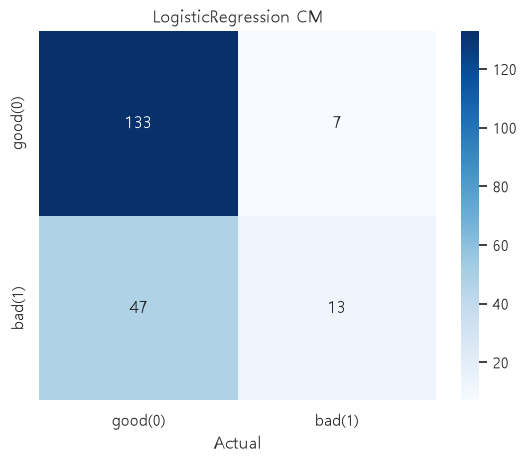

In [33]:
plot_confusion_matrix(lr_model, 'LogisticRegression', X_test, y_test)

In [34]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_result = check_metrics(nb_model, 'GaussianNB', X_train, X_test, y_train, y_test)
model_results.append(nb_result)

GaussianNB Train Predicton Accuracy: 0.7125
GaussianNB Train Predicton Precison: 0.5347
GaussianNB Train Predicton Recall: 0.3208
GaussianNB Train Predicton F1-score: 0.4010
-----------------------
GaussianNB Test Predicton Accuracy: 0.7400
GaussianNB Test Predicton Precison: 0.5952
GaussianNB Test Predicton Recall: 0.4167
GaussianNB Test Predicton F1-score: 0.4902


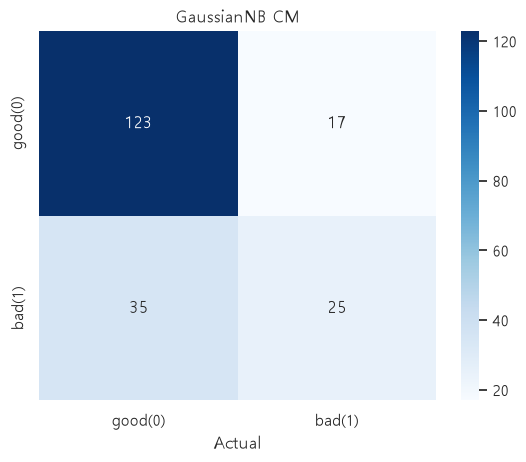

In [35]:
plot_confusion_matrix(nb_model, 'GaussianNB', X_test, y_test)

LR보단 낫긴 함

In [36]:
sv_model = SVC(random_state=SEED, C=10, kernel='rbf', probability=True)
sv_model.fit(X_train, y_train)
sv_result = check_metrics(sv_model, 'SupportVectorMachine', X_train, X_test, y_train, y_test)
model_results.append(sv_result)

SupportVectorMachine Train Predicton Accuracy: 0.7837
SupportVectorMachine Train Predicton Precison: 0.7557
SupportVectorMachine Train Predicton Recall: 0.4125
SupportVectorMachine Train Predicton F1-score: 0.5337
-----------------------
SupportVectorMachine Test Predicton Accuracy: 0.7600
SupportVectorMachine Test Predicton Precison: 0.7000
SupportVectorMachine Test Predicton Recall: 0.3500
SupportVectorMachine Test Predicton F1-score: 0.4667


c:\Users\playdata2\ML\ml_venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


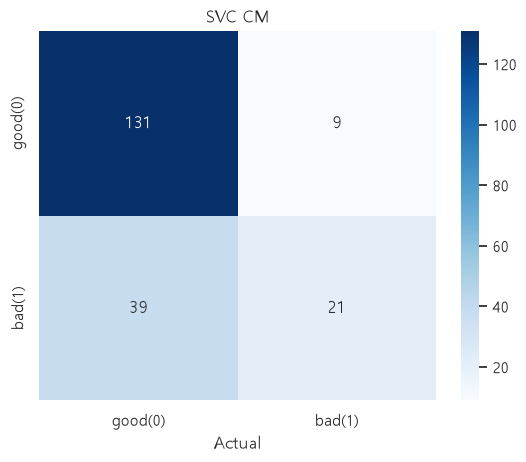

In [37]:
plot_confusion_matrix(sv_model, 'SVC', X_test, y_test)

In [38]:
dt_model = DecisionTreeClassifier(random_state=SEED, max_depth=8)
dt_model.fit(X_train, y_train)
dt_result = check_metrics(dt_model, 'DecisionTree', X_train, X_test, y_train, y_test)
model_results.append(dt_result)

DecisionTree Train Predicton Accuracy: 0.8512
DecisionTree Train Predicton Precison: 0.7410
DecisionTree Train Predicton Recall: 0.7750
DecisionTree Train Predicton F1-score: 0.7576
-----------------------
DecisionTree Test Predicton Accuracy: 0.7100
DecisionTree Test Predicton Precison: 0.5152
DecisionTree Test Predicton Recall: 0.5667
DecisionTree Test Predicton F1-score: 0.5397


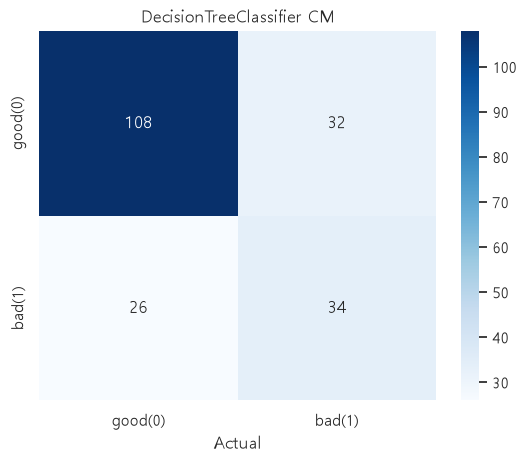

In [39]:
plot_confusion_matrix(dt_model, 'DecisionTreeClassifier', X_test, y_test)

max_depth 없어서 과적합

In [40]:
rf_model = RandomForestClassifier(random_state=SEED)
rf_model.fit(X_train, y_train)
rf_result = check_metrics(rf_model, 'RandomForest', X_train, X_test, y_train, y_test)
model_results.append(rf_result)

RandomForest Train Predicton Accuracy: 1.0000
RandomForest Train Predicton Precison: 1.0000
RandomForest Train Predicton Recall: 1.0000
RandomForest Train Predicton F1-score: 1.0000
-----------------------
RandomForest Test Predicton Accuracy: 0.7700
RandomForest Test Predicton Precison: 0.6667
RandomForest Test Predicton Recall: 0.4667
RandomForest Test Predicton F1-score: 0.5490


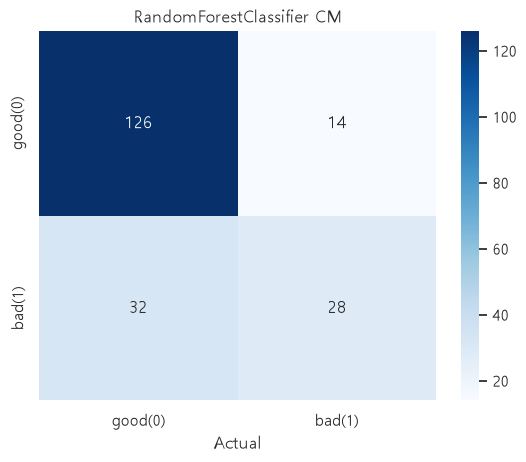

In [41]:
plot_confusion_matrix(rf_model, 'RandomForestClassifier', X_test, y_test)

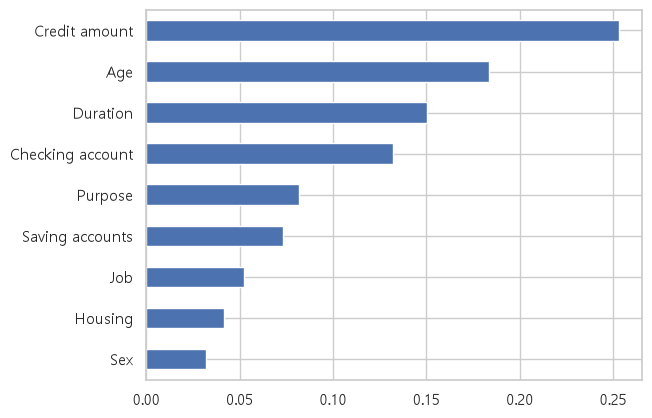

In [42]:
importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values()

importance.plot(kind='barh')
plt.show()

max_depth 없어서 과적합, 성능 개선 여지 존재

In [43]:
xgb_model = XGBClassifier(random_state=SEED)
xgb_model.fit(X_train, y_train)
xgb_result = check_metrics(xgb_model, 'XGBClassifier', X_train, X_test, y_train, y_test)
model_results.append(xgb_result)

XGBClassifier Train Predicton Accuracy: 1.0000
XGBClassifier Train Predicton Precison: 1.0000
XGBClassifier Train Predicton Recall: 1.0000
XGBClassifier Train Predicton F1-score: 1.0000
-----------------------
XGBClassifier Test Predicton Accuracy: 0.7450
XGBClassifier Test Predicton Precison: 0.5818
XGBClassifier Test Predicton Recall: 0.5333
XGBClassifier Test Predicton F1-score: 0.5565


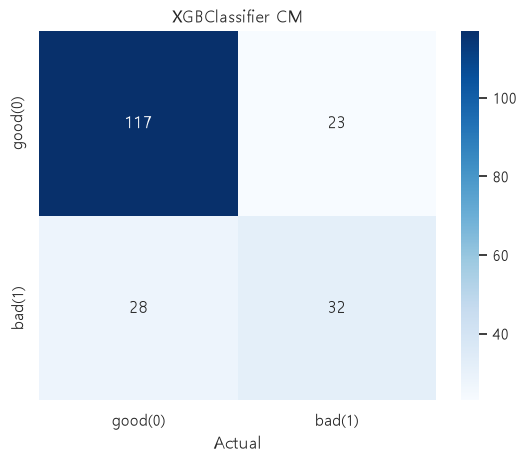

In [44]:
plot_confusion_matrix(xgb_model, 'XGBClassifier', X_test, y_test)

과적합 했으나 성능 개선 여지 존재

In [45]:
voting_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=SEED)),
        ('rf', RandomForestClassifier(random_state=SEED)),
        ('xgb', XGBClassifier(random_state=SEED)),
    ],
    voting='soft'   # 'hard' 또는 'soft'
)

voting_model.fit(X_train, y_train)

voting_result = check_metrics(
    voting_model,
    'VotingClassifier',
    X_train,
    X_test,
    y_train,
    y_test
)

model_results.append(voting_result)

VotingClassifier Train Predicton Accuracy: 0.9962
VotingClassifier Train Predicton Precison: 1.0000
VotingClassifier Train Predicton Recall: 0.9875
VotingClassifier Train Predicton F1-score: 0.9937
-----------------------
VotingClassifier Test Predicton Accuracy: 0.7600
VotingClassifier Test Predicton Precison: 0.6500
VotingClassifier Test Predicton Recall: 0.4333
VotingClassifier Test Predicton F1-score: 0.5200


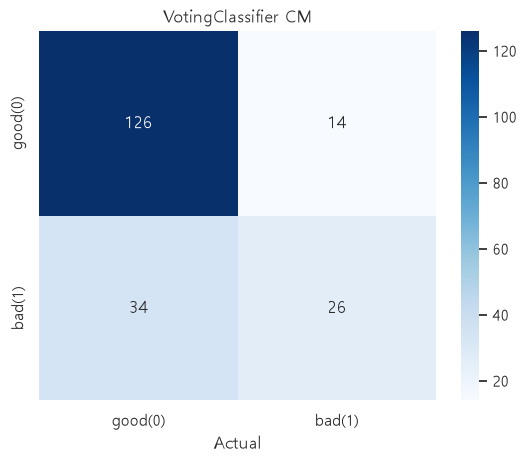

In [46]:
plot_confusion_matrix(voting_model, 'VotingClassifier', X_test, y_test)

In [47]:
df_model_results = pd.DataFrame(model_results).sort_values('f1_score', ascending=False)
df_model_results

,model,accuracy,precision,recall,f1_score
5,XGBClassifier,0.745,0.581818,0.533333,0.556522
4,RandomForest,0.770,0.666667,0.466667,0.549020
3,DecisionTree,0.710,0.515152,0.566667,0.539683
6,VotingClassifier,0.760,0.650000,0.433333,0.520000
1,GaussianNB,0.740,0.595238,0.416667,0.490196
2,SupportVectorMachine,0.760,0.700000,0.350000,0.466667
0,LogisticRegression,0.730,0.650000,0.216667,0.325000


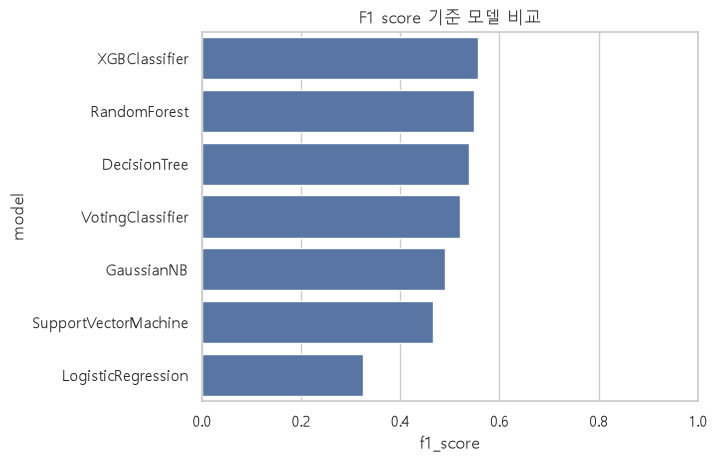

In [48]:
sns.barplot(data=df_model_results, x='f1_score', y='model')
plt.title('F1 score 기준 모델 비교')
plt.xlim(0, 1)
plt.show()

6. 클래스 불균형 문제
- 데이터 비율이 7:3이라서 SMOTE 사용해서 비율 맞추고 진행하면 성능개선 여지 존재

In [49]:
smote = SMOTE(random_state=SEED)

X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

print(f'증강된 X 데이터 수: {X_train_over.shape}, 증강된 y 데이터 수: {y_train_over.shape}')
print(pd.Series(y_train_over).value_counts())

증강된 X 데이터 수: (1120, 9), 증강된 y 데이터 수: (1120,)
Risk
1    560
0    560
Name: count, dtype: int64


In [52]:
xgb_over_model = XGBClassifier(random_state=SEED)
xgb_over_model.fit(X_train_over, y_train_over)

xgb_over_result = check_metrics(xgb_over_model, 'Reinforced XGBClassifier', X_train, X_test, y_train, y_test)
model_results.append(xgb_over_result)

Reinforced XGBClassifier Train Predicton Accuracy: 1.0000
Reinforced XGBClassifier Train Predicton Precison: 1.0000
Reinforced XGBClassifier Train Predicton Recall: 1.0000
Reinforced XGBClassifier Train Predicton F1-score: 1.0000
-----------------------
Reinforced XGBClassifier Test Predicton Accuracy: 0.7050
Reinforced XGBClassifier Test Predicton Precison: 0.5085
Reinforced XGBClassifier Test Predicton Recall: 0.5000
Reinforced XGBClassifier Test Predicton F1-score: 0.5042


실습 과제
1. 하이퍼파라미터 튜닝 (Optuna, GridSearchCV, RandomizedSearchCV)
2. 증강한 데이터로 학습하고 비교
3. Pipeline과 ColumnTransform 사용해서 전처리와 모델 학습 하나로 묶어서 임의의 데이터로 테스트

고도화 실습 과제
- 추론 모델을 함수형으로 모듈화시켜 streamlit에서 입력받은 값으로 출력 진행해보기

In [54]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [59]:
def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': SEED,
        'n_jobs': -1
    }

    model = RandomForestClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')

    return scores.mean()

In [62]:
sampler = TPESampler(seed=SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(rf_objective, n_trials=200, show_progress_bar=True)

best_params = study.best_params.copy()
rf_optuna_model = RandomForestClassifier(**best_params, random_state=SEED)
rf_optuna_model.fit(X_train, y_train)

rf_optuna_result = check_metrics(rf_optuna_model, 'Optuna RF', X_train, X_test, y_train, y_test)
model_results.append(rf_optuna_result)

Best trial: 22. Best value: 0.537028: 100%|██████████| 200/200 [15:05<00:00,  4.53s/it]


Optuna RF Train Predicton Accuracy: 0.9325
Optuna RF Train Predicton Precison: 0.9697
Optuna RF Train Predicton Recall: 0.8000
Optuna RF Train Predicton F1-score: 0.8767
-----------------------
Optuna RF Test Predicton Accuracy: 0.7550
Optuna RF Test Predicton Precison: 0.6122
Optuna RF Test Predicton Recall: 0.5000
Optuna RF Test Predicton F1-score: 0.5505


In [63]:
def rf_over_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': SEED,
        'n_jobs': -1
    }

    model = RandomForestClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)
    scores = cross_val_score(model, X_train_over, y_train_over, cv=cv, scoring='f1')

    return scores.mean()

sampler = TPESampler(seed=SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(rf_over_objective, n_trials=200, show_progress_bar=True)

best_params = study.best_params.copy()
rf_optuna_model = RandomForestClassifier(**best_params, random_state=SEED)
rf_optuna_model.fit(X_train_over, y_train_over)

rf_optuna_result = check_metrics(rf_optuna_model, 'Optuna RF', X_train, X_test, y_train, y_test)
model_results.append(rf_optuna_result)

Best trial: 152. Best value: 0.796261: 100%|██████████| 200/200 [10:09<00:00,  3.05s/it]


Optuna RF Train Predicton Accuracy: 1.0000
Optuna RF Train Predicton Precison: 1.0000
Optuna RF Train Predicton Recall: 1.0000
Optuna RF Train Predicton F1-score: 1.0000
-----------------------
Optuna RF Test Predicton Accuracy: 0.7050
Optuna RF Test Predicton Precison: 0.5082
Optuna RF Test Predicton Recall: 0.5167
Optuna RF Test Predicton F1-score: 0.5124


In [ ]:
df_clean = df_origin.copy()

In [71]:
df_clean.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [72]:
categorical_features = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
numeric_features = ['Age', 'Credit amount', 'Duration']

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

def rf_objective_pipeline(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': SEED,
        'n_jobs': -1
    }

    model = Pipeline([
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=SEED)),
        ('rf', RandomForestClassifier(**params))
    ])

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1'
    )

    return scores.mean()

sampler = TPESampler(seed=SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(rf_objective_pipeline, n_trials=200, show_progress_bar=True)

best_params = study.best_params.copy()
rf_pipeline_model = RandomForestClassifier(**best_params, random_state=SEED)
rf_pipeline_model.fit(X_train, y_train)

rf_pipeline_result = check_metrics(rf_pipeline_model, 'RF Pipeline', X_train, X_test, y_train, y_test)
model_results.append(rf_pipeline_result)

Best trial: 105. Best value: 0.596554: 100%|██████████| 200/200 [87:03:32<00:00, 1567.06s/it]      


RF Pipeline Train Predicton Accuracy: 0.8475
RF Pipeline Train Predicton Precison: 0.8391
RF Pipeline Train Predicton Recall: 0.6083
RF Pipeline Train Predicton F1-score: 0.7053
-----------------------
RF Pipeline Test Predicton Accuracy: 0.7550
RF Pipeline Test Predicton Precison: 0.6170
RF Pipeline Test Predicton Recall: 0.4833
RF Pipeline Test Predicton F1-score: 0.5421
